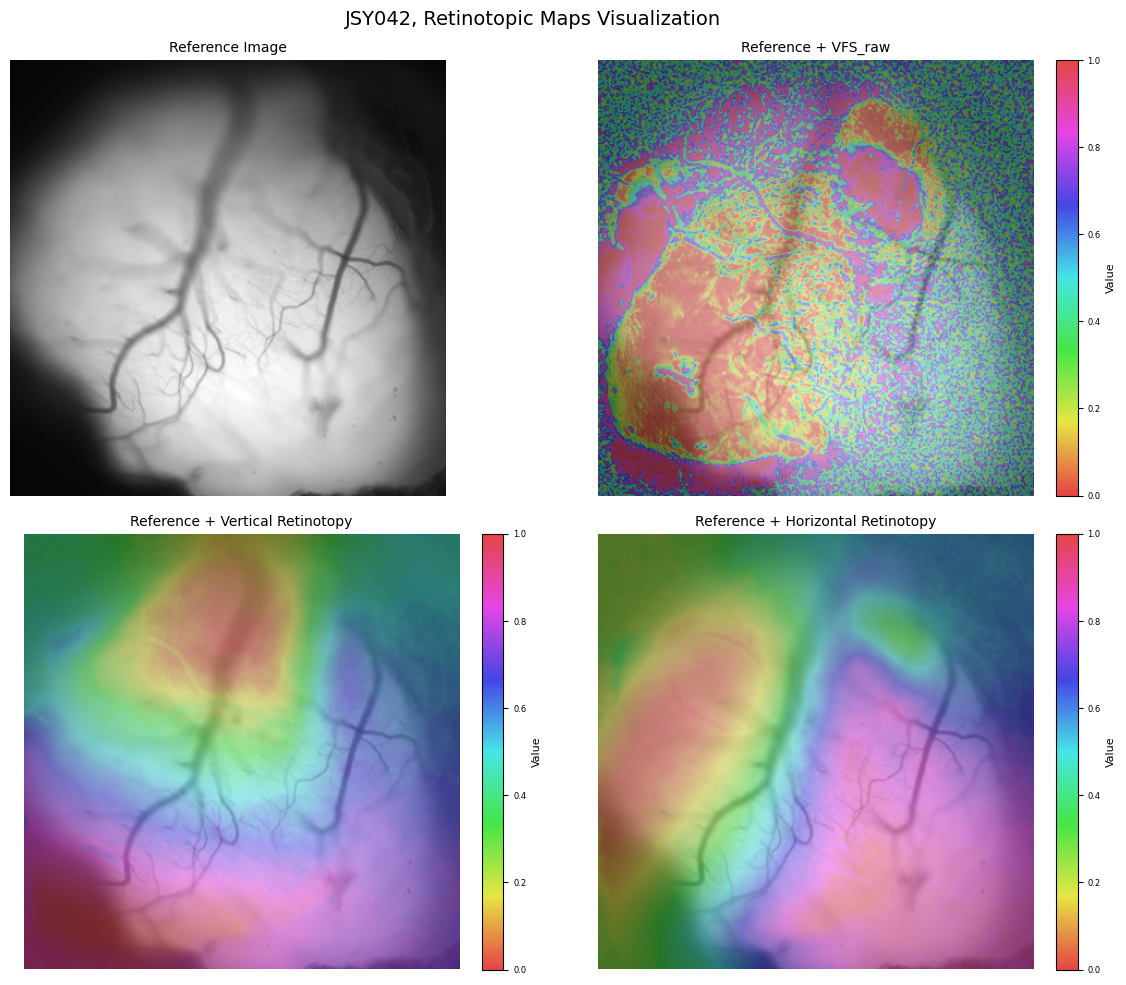

In [24]:
# Load .mat file and create 2x2 grid of visualizations
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb
import os

# Load the .mat file with full path
file_path = r'D:\V1_SpatialModulation\WF\250428_JSY_JSY042_SignMap\additional_maps.mat'
save_path = r'D:\V1_SpatialModulation\WF\250428_JSY_JSY042_SignMap'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")

# Load the .mat file
WF_data = scipy.io.loadmat(file_path)

# Extract the 'maps' structure
maps_struct = WF_data['maps'][0, 0]  # Access the first (and only) structure

# Extract all the arrays we need from the structure
ReferenceImage = np.squeeze(maps_struct['ReferenceImage'])
VFS_raw = np.squeeze(maps_struct['VFS_raw'])
VFS_processed = np.squeeze(maps_struct['VFS_processed'])
HorizontalRetinotopy = np.squeeze(maps_struct['HorizontalRetinotopy'])
VerticalRetinotopy = np.squeeze(maps_struct['VerticalRetinotopy'])

# Function to create overlay of reference image and retinotopic data
def create_overlay(ax, reference_img, retinotopic_data=None, alpha=0.5, title=''):
    # Normalize reference image to 0-1 for grayscale
    if reference_img.max() > 0:
        reference_img = reference_img / reference_img.max()
    
    # Enhance contrast of reference image to make it pop more
    reference_img = np.power(reference_img, 0.95)  # Gamma correction for better contrast
    
    # Display reference image in grayscale
    ax.imshow(reference_img, cmap='gray', vmin=0, vmax=1)
    
    # If retinotopic data is provided, create overlay
    if retinotopic_data is not None:
        # Normalize retinotopic data for HSV colormap if needed
        if retinotopic_data.max() > retinotopic_data.min():
            retinotopic_data = (retinotopic_data - retinotopic_data.min()) / (retinotopic_data.max() - retinotopic_data.min())
        
        # Create HSV image with modified saturation and value to let reference image show through
        h = retinotopic_data
        s = np.ones_like(retinotopic_data) * 0.7  # Reduced saturation
        v = np.ones_like(retinotopic_data) * 0.9  # Slightly reduced brightness
        
        # Stack HSV channels and convert to RGB
        hsv_img = np.stack([h, s, v], axis=2)
        rgb_img = hsv_to_rgb(hsv_img)
        
        # Overlay the HSV-colored retinotopic data on the reference image with reduced alpha
        im = ax.imshow(rgb_img, alpha=alpha)
        
        # Add a tiny colorbar with matching hsv settings
        custom_cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
            'hsv_modified', 
            [hsv_to_rgb(np.array([h, 0.7, 0.9])) for h in np.linspace(0, 1, 256)]
        )
        
        cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=custom_cmap), ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Value', fontsize=8)
        cbar.ax.tick_params(labelsize=6)
    
    # Add title
    ax.set_title(title, fontsize=10)
    ax.axis('off')  # Remove axes for cleaner look

# Create figure with 2x2 subplot grid
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1,1: Reference image alone
create_overlay(axs[0, 0], ReferenceImage, title='Reference Image')

# Plot 1,2: Overlay of reference image and VFS_raw
create_overlay(axs[0, 1], ReferenceImage, VFS_raw, title='Reference + VFS_raw')

# Plot 2,1: Overlay of reference image and vertical retinotopy
create_overlay(axs[1, 0], ReferenceImage, VerticalRetinotopy, title='Reference + Vertical Retinotopy')

# Plot 2,2: Overlay of reference image and horizontal retinotopy
create_overlay(axs[1, 1], ReferenceImage, HorizontalRetinotopy, title='Reference + Horizontal Retinotopy')

# Adjust layout
plt.tight_layout()
title = 'JSY042, Retinotopic Maps Visualization'
plt.suptitle(title, fontsize=14, y=0.98)
plt.subplots_adjust(top=0.93)

# Save the figure BEFORE showing it
if not os.path.exists(save_path):
    os.makedirs(save_path)

plt.savefig(os.path.join(save_path, 'retinotopic_maps_visualization.png'), dpi=300, bbox_inches='tight')

# Now show the figure (after saving)
plt.show()